<a href="https://colab.research.google.com/github/Sharmaluvkesh/Gender-Classification-Machine-Learning-Workflow/blob/main/gender_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gender Classification Machine Learning Workflow
This notebook guides you through an end-to-end classification pipeline tailored for the `gender_classification_v7.csv` dataset.

### Section 1: Library Imports & Loading Data
Bringing in all necessary tools for handling data, plotting, splitting datasets, and training the classification models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

In [2]:
# Loads your gender classification dataset into a pandas dataframe
df = pd.read_csv('gender_classification_v7.csv')
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


### Section 2: Data Exploration & Structural Check
Checking the shape of the dataset, looking for missing values, column data types, and verifying column alignment.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   long_hair                  5001 non-null   int64  
 1   forehead_width_cm          5001 non-null   float64
 2   forehead_height_cm         5001 non-null   float64
 3   nose_wide                  5001 non-null   int64  
 4   nose_long                  5001 non-null   int64  
 5   lips_thin                  5001 non-null   int64  
 6   distance_nose_to_lip_long  5001 non-null   int64  
 7   gender                     5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [4]:
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


### Section 3: Exploratory Data Analysis (EDA) via Visualizations
Analyzing relationships between the target feature (`gender`) and structural traits using distribution matrices and side-by-side bar plots.

In [5]:
df.groupby(['nose_wide', 'gender'])['gender'].count().unstack()

gender,Female,Male
nose_wide,,
0,2214,317
1,287,2183


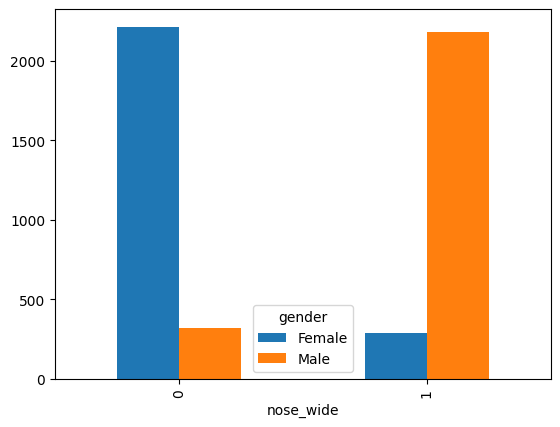

In [6]:
df.groupby(['nose_wide', 'gender'])['gender'].count().unstack().plot(kind='bar')
plt.show()

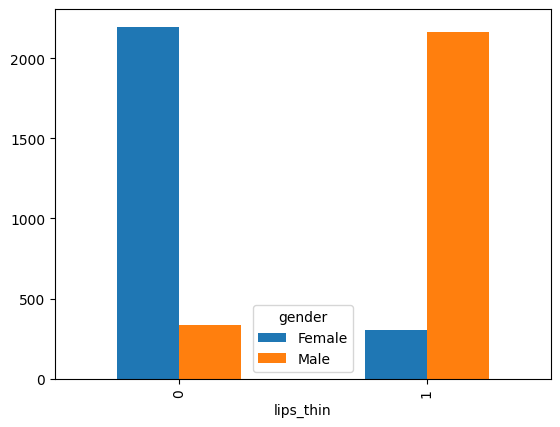

In [7]:
df.groupby(['lips_thin', 'gender'])['gender'].count().unstack().plot(kind='bar')
plt.show()

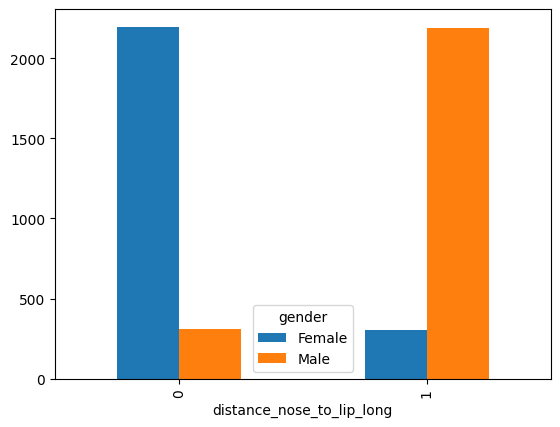

In [8]:
df.groupby(['distance_nose_to_lip_long', 'gender'])['gender'].count().unstack().plot(kind='bar')
plt.show()

In [9]:
df.columns

Index(['long_hair', 'forehead_width_cm', 'forehead_height_cm', 'nose_wide',
       'nose_long', 'lips_thin', 'distance_nose_to_lip_long', 'gender'],
      dtype='object')

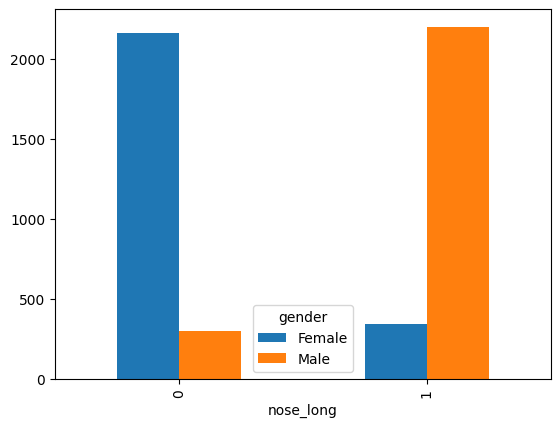

In [10]:
df.groupby(['nose_long', 'gender'])['gender'].count().unstack().plot(kind='bar')
plt.show()

In [11]:
df['gender'].value_counts()

,count
gender,
Female,2501
Male,2500


In [12]:
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


### Section 4: Feature Engineering & Target Mapping
Mapping string values in the target column to binary integers. (Your remaining features are already numerical flags, so `pd.get_dummies` is omitted).

In [13]:
df.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female


In [14]:
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

### Section 5: Splitting Features from Target
Isolating your independent features matrix ($X$) from your target label ($y$).

In [15]:
x = df.drop('gender', axis=1)
y = df['gender']

In [16]:
x.head()

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long
0,1,11.8,6.1,1,0,1,1
1,0,14.0,5.4,0,0,1,0
2,0,11.8,6.3,1,1,1,1
3,0,14.4,6.1,0,1,1,1
4,1,13.5,5.9,0,0,0,0


In [17]:
y.head()

,gender
0,1
1,0
2,1
3,1
4,0


### Section 6: Training and Testing Dataset Split
Allocating 70% of the data for training and holding out 30% for validation.

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

### Section 7: MODEL 1 — Logistic Regression

In [19]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [20]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [21]:
print('Train Confusion Matrix:-\n', confusion_matrix(y_train, train_pred))
print('Train Accuracy Score:-', accuracy_score(y_train, train_pred))
print('Train Precision Score:-', precision_score(y_train, train_pred))
print('Train Recall Score:-', recall_score(y_train, train_pred))

Train Confusion Matrix:-
 [[1707   55]
 [  51 1687]]
Train Accuracy Score:- 0.9697142857142858
Train Precision Score:- 0.9684270952927669
Train Recall Score:- 0.9706559263521288


In [22]:
print('Test Confusion Matrix:-\n', confusion_matrix(y_test, test_pred))
print('Test Accuracy Score:-', accuracy_score(y_test, test_pred))
print('Test Precision Score:-', precision_score(y_test, test_pred))
print('Test Recall Score:-', recall_score(y_test, test_pred))

Test Confusion Matrix:-
 [[715  24]
 [ 30 732]]
Test Accuracy Score:- 0.9640239840106596
Test Precision Score:- 0.9682539682539683
Test Recall Score:- 0.9606299212598425


### Section 8: MODEL 2 — Decision Tree Classifier

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [24]:
model = DecisionTreeClassifier()
model.fit(x_train, y_train)

DecisionTreeClassifier()

In [25]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [26]:
print('Train Confusion Matrix:-\n', confusion_matrix(y_train, train_pred))
print('Train Accuracy Score:-', accuracy_score(y_train, train_pred))
print('Train Precision Score:-', precision_score(y_train, train_pred))
print('Train Recall Score:-', recall_score(y_train, train_pred))

Train Confusion Matrix:-
 [[1762    0]
 [   3 1735]]
Train Accuracy Score:- 0.9991428571428571
Train Precision Score:- 1.0
Train Recall Score:- 0.9982738780207134


In [27]:
print('Test Confusion Matrix:-\n', confusion_matrix(y_test, test_pred))
print('Test Accuracy Score:-', accuracy_score(y_test, test_pred))
print('Test Precision Score:-', precision_score(y_test, test_pred))
print('Test Recall Score:-', recall_score(y_test, test_pred))

Test Confusion Matrix:-
 [[709  30]
 [ 34 728]]
Test Accuracy Score:- 0.9573617588274483
Test Precision Score:- 0.9604221635883905
Test Recall Score:- 0.9553805774278216


### Section 9: MODEL 3 — Random Forest Classifier

In [28]:
model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [29]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [30]:
print('Train Confusion Matrix:-\n', confusion_matrix(y_train, train_pred))
print('Train Accuracy Score:-', accuracy_score(y_train, train_pred))
print('Train Precision Score:-', precision_score(y_train, train_pred))
print('Train Recall Score:-', recall_score(y_train, train_pred))

Train Confusion Matrix:-
 [[1762    0]
 [   3 1735]]
Train Accuracy Score:- 0.9991428571428571
Train Precision Score:- 1.0
Train Recall Score:- 0.9982738780207134


In [31]:
print('Test Confusion Matrix:-\n', confusion_matrix(y_test, test_pred))
print('Test Accuracy Score:-', accuracy_score(y_test, test_pred))
print('Test Precision Score:-', precision_score(y_test, test_pred))
print('Test Recall Score:-', recall_score(y_test, test_pred))

Test Confusion Matrix:-
 [[713  26]
 [ 33 729]]
Test Accuracy Score:- 0.960692871419054
Test Precision Score:- 0.9655629139072848
Test Recall Score:- 0.9566929133858267
